In [1]:
import astropy.units as u
from sunpy.net import Fido, attrs as a
import dkist.net
import dkist
import utilvbi
import destretch_fw as destr

from astropy.io import fits
import numpy as np
from IPython.display import Video
from astropy.io import fits
import matplotlib.pyplot as plt
import os

import astropy.io.fits as pf
import utilvbi
import skimage
from skimage.exposure import match_histograms

import matplotlib.pyplot as plt
import numpy as np
import pooch

import astropy.units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from astropy.visualization import quantity_support
from astropy.wcs.utils import wcs_to_celestial_frame

from sunpy.coordinates.frames import Helioprojective

from irispy.io import read_files

quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x32a6e6ba0>

In [2]:
filenameSJI1330 = '/Users/coletamburri/Desktop/iris_l2_20241003_072127_4204700237_SJI_1330_t000.fits'
raster_filename = '/Users/coletamburri/Desktop/iris_l2_20241003_072127_4204700237_raster_t000_r00000.fits'

In [3]:
# using irispy
raster = read_files(raster_filename, memmap=False)


In [4]:
print(raster)


Raster Collection
-----------------
Spectral Windows (cube keys): (np.str_('C II 1336'), np.str_('Si IV 1403'), np.str_('2814'), np.str_('Mg II k 2796'))
Number of Cubes: 4
Aligned dimensions: [1 26375 204]
Aligned physical types: [('meta.obs.sequence',), ('custom:pos.helioprojective.lat', 'time', 'custom:pos.helioprojective.lon'), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon')]



In [6]:
CII = raster["C II 1336"]
SiIV = raster["Si IV 1403"]
MgIIk = raster["Mg II k 2796"]


In [7]:
CII

2026-04-22 13:38:56 - astropy - WARNING: target cannot be converted to ICRS, so will not be set on SpectralCoord


SpectrogramCubeSequence
-----------------------
Time Range: ['2024-10-03 07:21:27.528' '2024-10-03 13:21:44.518']
Pixel Dimensions: (1, 26375, 204, 167)
Longitude range: [59.33183744 60.09255021] arcsec
Latitude range: [-412.55477529 -345.09522471] arcsec
Spectral range: [1.33265029e-07 1.33695965e-07] m
Data unit: DN_IRIS_FUV

In [10]:
%matplotlib widget

2026-04-22 13:39:09 - astropy - WARNING: target cannot be converted to ICRS, so will not be set on SpectralCoord
/opt/anaconda3/lib/python3.13/site-packages/mpl_animators/base.py:353: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  sframe = widgets.Slider(self.sliders[-1], "",


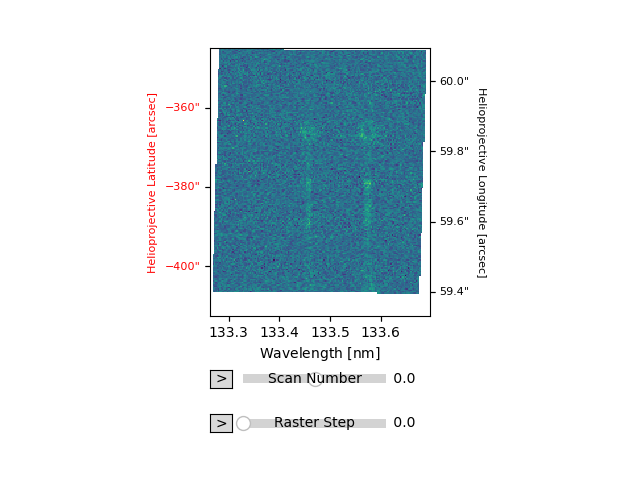

In [11]:
fig = plt.figure()
CII.plot(fig=fig)

In [118]:
SJI = fits.open(filenameSJI1330)
raster = fits.open(raster_filename)

In [90]:
np.shape(SJI[0].data)

(2625, 204, 176)

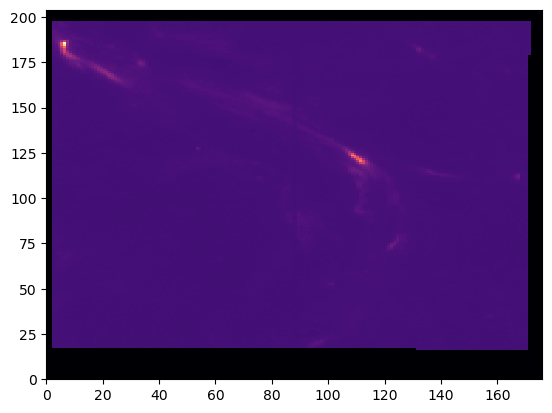

In [110]:
plt.pcolormesh(SJI[0].data[900,:,:],cmap='magma')


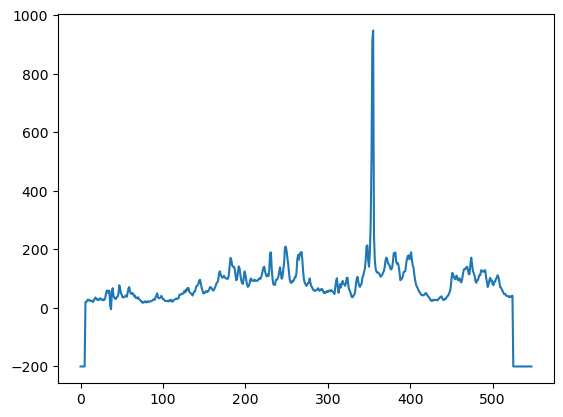

In [40]:
plt.plot(irisMarch72025[0].data[20,:,513])

In [32]:
np.shape(irisMarch72025[1].data)

(80, 31)

In [33]:
irisMarch72025[1].data[0]

array([ 1.00000000e-01,  5.52148247e+01,  9.33270097e-01,  8.00011444e+00,
        5.93572512e+02,  2.54750000e+02,  2.00000000e+00,  2.00000000e+00,
        1.50999999e+00,  0.00000000e+00, -7.11665346e+01,  1.02133759e+02,
        1.55178772e+03,  2.32416585e-01,  9.99936581e-01,  1.12606091e-02,
       -1.12606091e-02,  9.99936581e-01,  0.00000000e+00,  0.00000000e+00,
        4.75240250e+01,  2.50040264e+01,  1.90140247e+01,  2.18840256e+01,
        1.89938984e+01,  2.15280514e+01,  2.50459747e+01,  6.92402554e+00,
       -2.59999990e-01, -2.70000011e-01,  1.90000000e+01], dtype='>f8')

In [35]:
irisMarch72025[0].header

SIMPLE  =                    T / Written by IDL:  Sat Jul  5 03:10:34 2025      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  845 /                                                
NAXIS2  =                  548 /                                                
NAXIS3  =                   80 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2025-07-05'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    
TELESCOP= 'IRIS    '           /                                                
INSTRUME= 'SJI     '           /                                                
DATA_LEV=              2.000

In [119]:
raster[0].header

SIMPLE  =                    T / Written by IDL:  Fri Jun 13 16:54:29 2025      
BITPIX  =                   16 / Number of bits per data pixel                  
NAXIS   =                    0 / Number of data axes                            
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2025-06-13'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    
TELESCOP= 'IRIS    '           /                                                
INSTRUME= 'SPEC    '           /                                                
DATA_LEV=              2.00000 /                                                
LVL_NUM =              2.00000 /                                                
VER_RF2 = 'L12-2019-08-08'     /                                                
DATE_RF2= '2025-06-12T17:59:

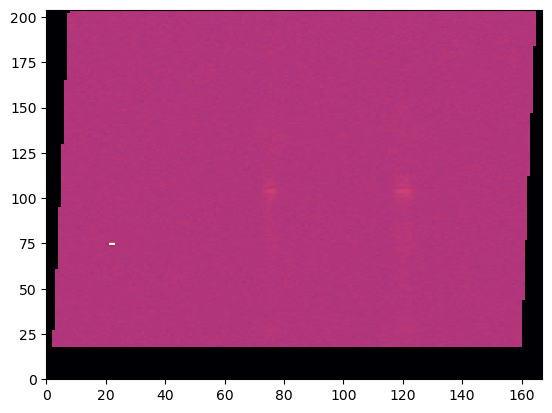

In [122]:
plt.pcolormesh(raster[1].data[2000,:,:],cmap='magma')